# Importação das bibliotecas

Nesta etapa são importadas as bibliotecas que serão utilizadas durante toda a análise exploratória.

In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Carregamento da base de dados

A base de dados foi carregada utilizando a biblioteca Pandas. 
A partir deste momento serão realizadas verificações para compreender sua estrutura e qualidade.

## Primeiras observações

A função `head( ite visualizar os primeiros registros da base de dados, auxiliando na identificação inicial das variáveis disponíveis e na compreensão da estrutura do conjunto de dados.

In [3]:
    

# Carregando a base de dados do desafio
df = pd.read_csv("../data/desafio_nps_fase_1.csv")

# Visualizando as 5 primeiras linhas
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


 ## Tratamento inicial dos dados e Renomeação das Colunas
 
 Ajuste dos nomes das colunas conforme o mapeamento definido para o projeto, garantindo a padronização para as próximas etapas de análise.

In [4]:
# Renomeando as colunas conforme o alias do projeto

df = df.rename(columns={
    "customer_id": "id_cliente",
    "customer_age": "idade",
    "customer_region": "regiao",
    "customer_tenure_months": "tempo_cliente_meses",

    "order_id": "id_pedido",
    "order_value": "valor_pedido",
    "items_quantity": "quantidade_itens",
    "discount_value": "valor_desconto",
    "payment_installments": "parcelas",

    "delivery_time_days": "tempo_entrega",
    "delivery_delay_days": "atraso_entrega",
    "freight_value": "valor_frete",
    "delivery_attempts": "tentativas_entrega",

    "customer_service_contacts": "contatos_atendimento",
    "resolution_time_days": "tempo_resolucao",

    "complaints_count": "reclamacoes",

    "repeat_purchase_30d": "recompra_30_dias",
    "csat_internal_score": "csat",

    "nps_score": "nps"
})

 ## Validação dos dados  
 
 Antes do início das análises exploratórias, foi realizada uma avaliação da qualidade dos dados, contemplando a verificação de valores ausentes, registros duplicados e consistência das variáveis. Essa etapa garante maior confiabilidade às análises posteriores, reduzindo o risco de interpretações equivocadas decorrentes de problemas na base de dados.
 
 Foi realizada a verificação da estrutura da base utilizando os métodos `info()`, `describe()`, `isnull()` e `duplicated()`. Não foram identificados valores ausentes nem registros duplicados, indicando que a base está consistente para as análises exploratórias.

In [5]:

# Verifica a quantidade de linhas e colunas do DataFrame
df.shape

(2500, 19)

In [6]:

# Exibe o nome de todas as colunas presentes na base (já renomeadas)
df.columns

Index(['id_cliente', 'idade', 'regiao', 'tempo_cliente_meses', 'id_pedido',
       'valor_pedido', 'quantidade_itens', 'valor_desconto', 'parcelas',
       'tempo_entrega', 'atraso_entrega', 'valor_frete', 'tentativas_entrega',
       'contatos_atendimento', 'tempo_resolucao', 'nps', 'recompra_30_dias',
       'reclamacoes', 'csat'],
      dtype='str')

In [7]:

# Resumo estatístico das variáveis numéricas
df.describe()

,id_cliente,idade,tempo_cliente_meses,id_pedido,valor_pedido,quantidade_itens,valor_desconto,parcelas,tempo_entrega,atraso_entrega,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao,nps,recompra_30_dias,reclamacoes,csat
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


In [8]:

# Contagem de valores nulos por coluna
df.isnull().sum()

id_cliente              0
idade                   0
regiao                  0
tempo_cliente_meses     0
id_pedido               0
valor_pedido            0
quantidade_itens        0
valor_desconto          0
parcelas                0
tempo_entrega           0
atraso_entrega          0
valor_frete             0
tentativas_entrega      0
contatos_atendimento    0
tempo_resolucao         0
nps                     0
recompra_30_dias        0
reclamacoes             0
csat                    0
dtype: int64

In [9]:

# Identifica e exibe a quantidade de linhas duplicadas na base
duplicados = df.duplicated().sum()
print(f"Total de duplicidade = {duplicados}")

Total de duplicidade = 0


## Estrutura da base

 A base possui **2.500 registros** distribuídos em **19 variáveis**.
 
 Foram identificadas variáveis numéricas e categóricas, representando informações referentes ao cliente, pedido, entrega, atendimento e satisfação.
 
 Não foram observados valores ausentes durante esta etapa.

In [10]:

# Resumo estatístico focado exclusivamente na nota do NPS
df["nps"].describe()

count    2500.000000
mean        4.378600
std         2.510229
min         0.000000
25%         2.600000
50%         4.400000
75%         6.100000
max        10.000000
Name: nps, dtype: float64

In [11]:

# Calcula a mediana das notas de NPS
media= df["nps"].mean()
print(f"Calculo = {media}")

Calculo = 4.3786


In [12]:

# Calcula a mediana das notas de NPS
mediana= df["nps"].median()
print(f"Calculo = {mediana}")

Calculo = 4.4


In [13]:

# Identifica a nota mais frequente (moda) do NPS
moda = df["nps"].mode()
print(f"Calculo moda = \n{moda}")

Calculo moda = 
0    0.0
Name: nps, dtype: float64


A proximidade entre média (4,37) e mediana (4,40) indica uma distribuição relativamente estável das notas. Entretanto, a moda igual a zero revela que a nota mais frequente atribuída pelos clientes foi a pior possível, reforçando o cenário de baixa satisfação observado ao longo da análise.

In [14]:

# Contagem de registros para cada nota de NPS, ordenada pela nota
df["nps"].value_counts().sort_index()

nps
0.0     158
0.1       8
0.2      14
0.3      10
0.4      14
       ... 
9.6       8
9.7       3
9.8       4
9.9       3
10.0     42
Name: count, Length: 101, dtype: int64

In [15]:
# Criação de uma coluna auxiliar para facilitar a análise das notas
df["nps_arredondado"] = df["nps"].round().astype(int)

In [16]:
df["nps_arredondado"].value_counts().sort_index()

nps_arredondado
0     213
1     133
2     277
3     300
4     392
5     328
6     358
7     206
8     145
9      82
10     66
Name: count, dtype: int64

Dos 2.500 registros analisados, apenas 42 clientes atribuíram nota máxima (10,0). Ao considerar as notas arredondadas, 66 clientes ficaram na faixa correspondente à nota 10 (entre aproximadamente 9,5 e 10). Esse resultado evidencia uma baixa proporção de avaliações máximas, sugerindo que a empresa possui poucos clientes que classificam sua experiência como excelente.

 ## Distribuição Visual do NPS

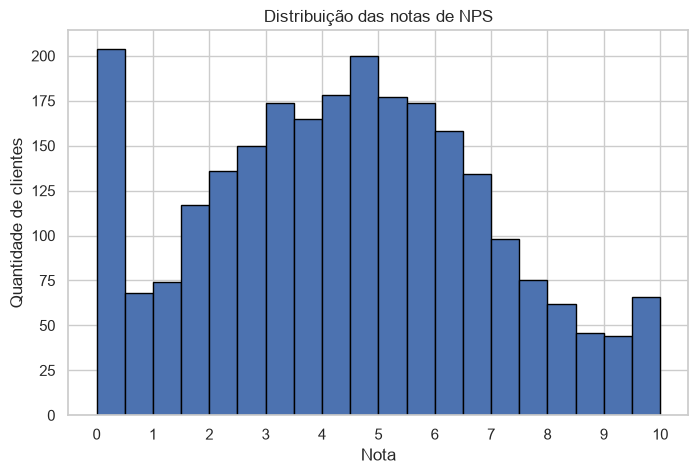

In [17]:
# %%
# Configuração e exibição do histograma de distribuição das notas
plt.figure(figsize=(8 , 5))
plt.hist(df["nps"], bins=20, edgecolor="black")  # adicionei borda para melhor visualização
plt.title("Distribuição das notas de NPS")
plt.xlabel("Nota")
plt.ylabel("Quantidade de clientes")
plt.xticks(range(0, 11))

plt.show()

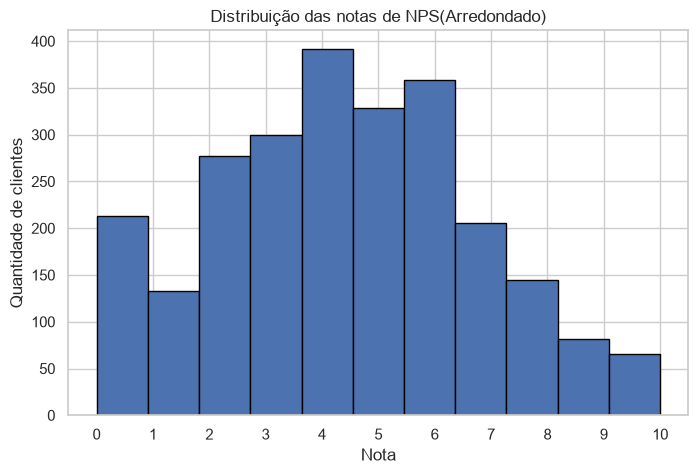

In [18]:
# %%
# Configuração e exibição do histograma de distribuição das notas
plt.figure(figsize=(8 , 5))
plt.hist(df["nps_arredondado"], bins=11, edgecolor="black")  # adicionei borda para melhor visualização
plt.title("Distribuição das notas de NPS(Arredondado)")
plt.xlabel("Nota")
plt.ylabel("Quantidade de clientes")
plt.xticks(range(0, 11))

plt.show()

## Categorização do NPS
 Criação da variável categórica para classificar as notas em Detritores, Neutros e Promotores.

In [19]:
def categoria_nps(nota):
    if nota <= 6:
        return "Detrator"
    elif nota <= 8:
        return "Neutro"
    else:
        return "Promotor"

df["categoria_nps"] = df["nps"].apply(categoria_nps)
df["categoria_nps"].value_counts()

categoria_nps
Detrator    1851
Neutro       448
Promotor     201
Name: count, dtype: int64

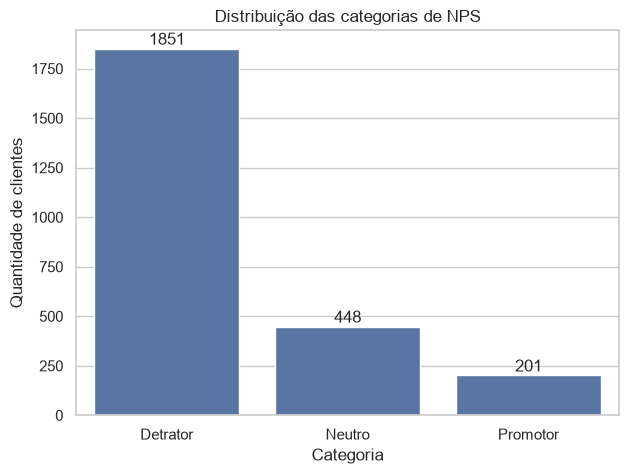

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="categoria_nps",
    order=["Detrator", "Neutro", "Promotor"]
)

plt.title("Distribuição das categorias de NPS")
plt.xlabel("Categoria")
plt.ylabel("Quantidade de clientes")
for i, valor in enumerate(df["categoria_nps"].value_counts().loc[
    ["Detrator", "Neutro", "Promotor"]
]):
    plt.text(i, valor + 20, str(valor), ha="center")
plt.show()

### Análise

A classificação das notas de NPS demonstra que a maior parte dos clientes é composta por detratores. Dos 2.500 registros analisados, 1.851 (74,0%) pertencem a essa categoria, enquanto apenas 201 clientes (8,0%) são classificados como promotores.

Esse resultado evidencia um baixo nível de satisfação geral, indicando que a empresa apresenta um elevado percentual de clientes insatisfeitos, reforçando a necessidade de identificar os fatores operacionais que contribuem para a formação de detratores. A predominância de detratores reforça a necessidade de identificar os fatores operacionais que mais impactam negativamente a percepção dos clientes, como atrasos, reclamações e necessidade de múltiplos contatos com o atendimento.

## Análise dos fatores que influenciam o NPS
 
 Após compreender a estrutura e a qualidade da base de dados, inicia-se a análise das variáveis que podem influenciar a satisfação dos clientes. O objetivo desta etapa é identificar quais aspectos da operação apresentam maior relação com o NPS e quais fatores estão mais associados à formação de clientes promotores e detratores.

## Contatos com o atendimento
O objetivo desta análise é verificar como a quantidade de contatos realizados com o atendimento está relacionada ao NPS dos clientes, buscando identificar se a necessidade de múltiplas interações influencia a satisfação.


In [21]:
dfcontatos_atendimento = df["contatos_atendimento"].value_counts().sort_values()
dfcontatos_atendimento


contatos_atendimento
7      3
6      7
5     34
4    132
3    314
0    554
2    640
1    816
Name: count, dtype: int64

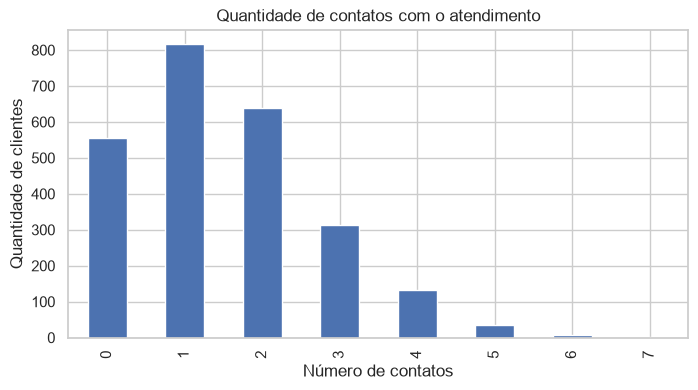

In [22]:
# Quantidade de contatos com o atendimento
df["contatos_atendimento"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Quantidade de contatos com o atendimento")
plt.xlabel("Número de contatos")
plt.ylabel("Quantidade de clientes")
plt.show()

In [23]:
# Calculando a média do NPS agrupado por contatos de atendimento
media_nps_contatos_atendimento = (
    df.groupby("contatos_atendimento")["nps"]
      .mean()
      .reset_index()
)

media_nps_contatos_atendimento

,contatos_atendimento,nps
0,0,5.543502
1,1,4.657108
2,2,4.116406
3,3,3.201911
4,4,2.654545
5,5,2.238235
6,6,0.742857
7,7,1.200000


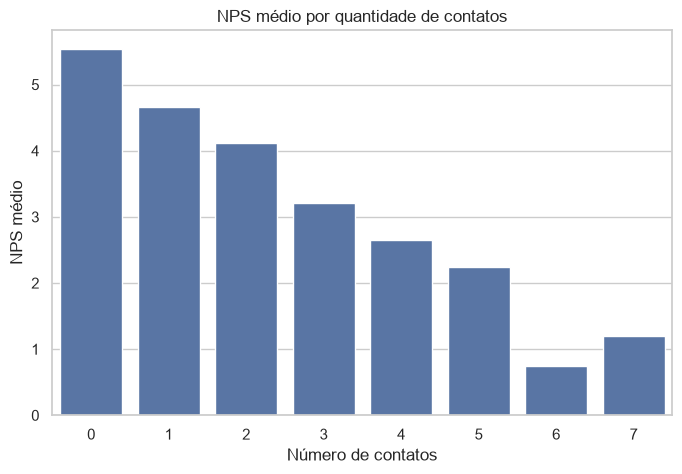

In [24]:
#Configuração e exibição do gráfico de barras de NPS médio por quantidade de contatos
plt.figure(figsize=(8, 5))

sns.barplot(
    data=media_nps_contatos_atendimento,
    x="contatos_atendimento",
    y="nps"
)

plt.title("NPS médio por quantidade de contatos")
plt.xlabel("Número de contatos")
plt.ylabel("NPS médio")
plt.show()

In [25]:
# Tabela de cruzamento percentual entre quantidade de contatos e categoria de NPS
tabela = (
    pd.crosstab(
        df["contatos_atendimento"],
        df["categoria_nps"],
        normalize="index"
    ) * 100
).round(1)

tabela

categoria_nps,Detrator,Neutro,Promotor
contatos_atendimento,,,
0,59.2,23.8,17.0
1,70.3,21.4,8.2
2,79.1,16.1,4.8
3,88.5,8.9,2.5
4,92.4,6.8,0.8
5,97.1,2.9,0.0
6,100.0,0.0,0.0
7,100.0,0.0,0.0



### Análise

Inicialmente, observa-se que a maior parte dos clientes necessitou de apenas um ou dois contatos com o atendimento, enquanto um número reduzido precisou retornar diversas vezes.

Ao analisar a média do NPS por quantidade de contatos, identifica-se uma relação inversa entre essas variáveis. Clientes que não precisaram acionar o atendimento apresentaram média de NPS de 5,54. À medida que o número de contatos aumenta, essa média reduz gradativamente, chegando a 0,74 para clientes que realizaram seis contatos.

O cruzamento entre a quantidade de contatos e as categorias do NPS reforça essa conclusão. Entre os clientes que não entraram em contato com o atendimento, 17% são promotores. Já entre aqueles que realizaram quatro ou mais contatos, praticamente todos são classificados como detratores.

Esses resultados indicam que a necessidade de múltiplos contatos está fortemente associada à redução da satisfação do cliente, sugerindo dificuldades na resolução dos problemas já no primeiro atendimento.

## Reclamações

O objetivo desta análise é avaliar como a quantidade de reclamações registradas está relacionada ao NPS, verificando se o aumento das ocorrências influencia a satisfação dos clientes.

In [26]:
media_nps_reclamacoes = (
    df.groupby("reclamacoes")["nps"]
      .mean()
      .reset_index()
)

media_nps_reclamacoes

,reclamacoes,nps
0,0,8.517391
1,1,7.770492
2,2,6.052347
3,3,4.910059
4,4,4.219167
5,5,3.645270
6,6,3.062030
7,7,2.813609
8,8,2.065079
9,9,2.487500


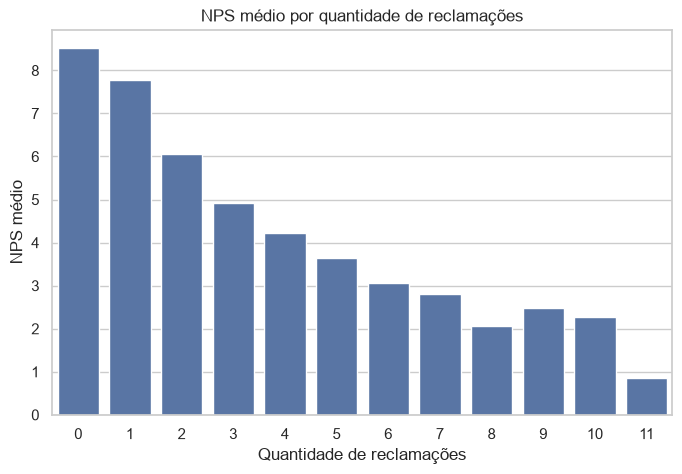

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=media_nps_reclamacoes,
    x="reclamacoes",
    y="nps"
)

plt.title("NPS médio por quantidade de reclamações")
plt.xlabel("Quantidade de reclamações")
plt.ylabel("NPS médio")

plt.show()

In [28]:
tabela = (
    pd.crosstab(
        df["reclamacoes"],
        df["categoria_nps"],
        normalize="index"
    ) * 100
).round(1)

tabela

categoria_nps,Detrator,Neutro,Promotor
reclamacoes,,,
0,4.3,34.8,60.9
1,8.2,50.0,41.8
2,43.3,38.6,18.1
3,67.7,24.3,8.1
4,81.2,13.7,5.2
5,88.3,9.7,2.0
6,93.6,6.4,0.0
7,93.5,4.1,2.4
8,100.0,0.0,0.0


### Análise

Observa-se uma relação inversa entre a quantidade de reclamações registradas e o NPS médio. Clientes que não apresentaram reclamações registraram média de NPS de 8,52, enquanto aqueles com maior número de reclamações apresentaram redução progressiva dessa média.

Esse comportamento indica que o aumento do volume de reclamações está diretamente associado à diminuição da satisfação dos clientes. Quanto maior a quantidade de problemas registrados durante a experiência de compra, maior a probabilidade de o cliente tornar-se um detrator.

O cruzamento entre a quantidade de reclamações e as categorias do NPS reforça essa conclusão, evidenciando que clientes com maior número de reclamações concentram percentuais cada vez maiores de detratores.

Esses resultados indicam que a quantidade de reclamações é um dos principais fatores associados à redução da satisfação dos clientes, evidenciando que problemas recorrentes ao longo da jornada de compra impactam negativamente a percepção da experiência.

## Atraso na entrega

O objetivo desta análise é avaliar o impacto dos dias de atraso na entrega sobre o NPS dos clientes, verificando se atrasos maiores estão associados à redução da satisfação.

In [29]:
media_nps_atraso_entrega = (
    df.groupby("atraso_entrega")["nps"]
      .mean()
      .reset_index()
)

media_nps_atraso_entrega

,atraso_entrega,nps
0,0,6.856679
1,1,5.546179
2,2,4.580186
3,3,3.436762
4,4,2.444444
5,5,1.481034
6,6,1.097059
7,7,0.292857
8,8,0.000000


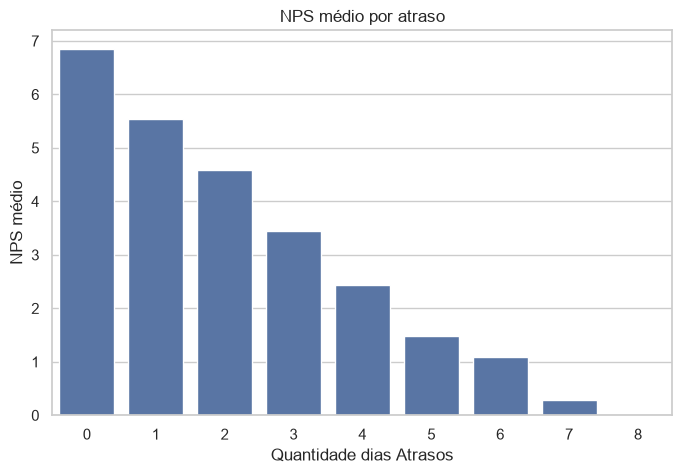

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=media_nps_atraso_entrega,
    x="atraso_entrega",
    y="nps"
)

plt.title("NPS médio por atraso")
plt.xlabel("Quantidade dias Atrasos")
plt.ylabel("NPS médio")

plt.show()

In [31]:
tabela = (
    pd.crosstab(
        df["atraso_entrega"],
        df["categoria_nps"],
        normalize="index"
    ) * 100
).round(1)

tabela

categoria_nps,Detrator,Neutro,Promotor
atraso_entrega,,,
0,36.5,32.5,31.0
1,59.7,26.3,14.0
2,75.4,21.2,3.4
3,89.7,9.1,1.1
4,95.9,3.7,0.4
5,99.1,0.9,0.0
6,100.0,0.0,0.0
7,100.0,0.0,0.0
8,100.0,0.0,0.0


### Análise

Os resultados evidenciam uma forte relação entre o atraso na entrega e a satisfação dos clientes. Observa-se uma redução contínua do NPS médio conforme aumentam os dias de atraso, passando de 6,86 para clientes sem atraso para 0,00 entre aqueles que receberam o pedido com oito dias de atraso.

O cruzamento entre os dias de atraso e as categorias do NPS confirma essa tendência. Entre os clientes que não sofreram atraso, aproximadamente 31,0% são promotores. Entretanto, à medida que o atraso aumenta, a participação de promotores diminui rapidamente, enquanto a proporção de detratores cresce até atingir 100% dos clientes a partir de seis dias de atraso.

Esses resultados indicam que o atraso na entrega é um dos fatores que mais impactam negativamente a percepção da experiência do cliente, aumentando significativamente a probabilidade de avaliações baixas e da formação de clientes detratores.

## Tempo de resolução

O objetivo desta análise é analisar como o tempo necessário para resolução das solicitações dos clientes influencia o NPS, verificando se atendimentos mais demorados estão associados a menores níveis de satisfação.

In [32]:
media_nps_tempo_resolucao = (
    df.groupby("tempo_resolucao")["nps"]
     .mean()
     .reset_index()
)
media_nps_tempo_resolucao

,tempo_resolucao,nps
0,0,5.320192
1,1,5.004167
2,2,4.817904
3,3,4.627848
4,4,4.442233
5,5,4.423295
6,6,4.324365
7,7,4.260563
8,8,3.965639
9,9,4.045588


Text(0, 0.5, 'Nps Médio')

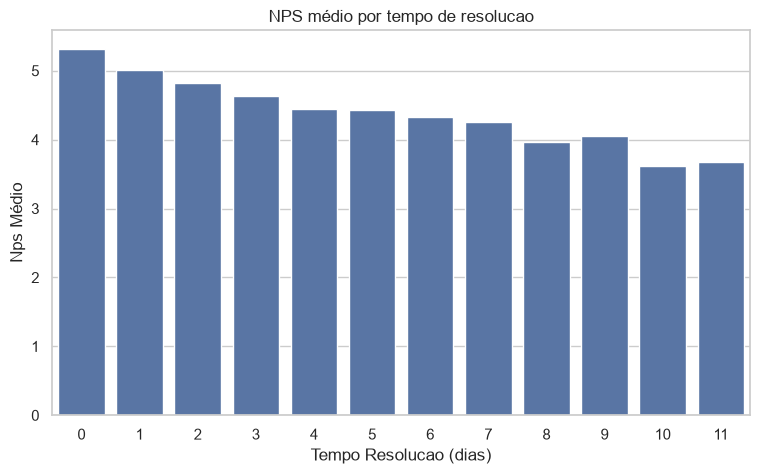

In [33]:
plt.figure (figsize=(9,5))

sns.barplot(
    data=media_nps_tempo_resolucao,
    x="tempo_resolucao",
    y="nps"
)

plt.title("NPS médio por tempo de resolucao")
plt.xlabel("Tempo Resolucao (dias)")
plt.ylabel("Nps Médio")


In [34]:
tabela = (
    pd.crosstab(
        df["tempo_resolucao"],
        df["categoria_nps"],
        normalize="index"
    ) * 100
).round(1)

tabela

categoria_nps,Detrator,Neutro,Promotor
tempo_resolucao,,,
0,60.1,26.0,13.9
1,64.1,24.0,12.0
2,68.1,21.8,10.0
3,70.0,17.3,12.7
4,75.2,15.5,9.2
5,75.0,19.3,5.7
6,75.6,15.2,9.1
7,76.5,17.4,6.1
8,79.7,15.9,4.4


### Análise

Observa-se uma tendência de redução gradual do NPS conforme aumenta o tempo necessário para resolução dos problemas dos clientes. Embora a diminuição seja menos intensa quando comparada ao atraso na entrega, clientes que aguardam mais tempo para terem suas solicitações resolvidas apresentam, em média, menores níveis de satisfação.

O cruzamento entre o tempo de resolução e as categorias do NPS reforça esse comportamento, demonstrando aumento progressivo da participação de clientes detratores e redução da proporção de promotores à medida que o tempo de resolução aumenta.

Esses resultados indicam que a agilidade na resolução dos problemas influencia positivamente a experiência do cliente, embora seu impacto seja menos acentuado do que fatores relacionados à logística e ao volume de reclamações.

## Tentativas de entrega

O objetivo desta análise é verificar se a quantidade de tentativas de entrega apresenta relação com o NPS dos clientes, buscando identificar se múltiplas tentativas influenciam a satisfação.

In [35]:
media_nps_tentativas_entrega = (
    df.groupby("tentativas_entrega")["nps"]
     .mean()
     .reset_index()
)
media_nps_tentativas_entrega


,tentativas_entrega,nps
0,1,4.353034
1,2,4.259905
2,3,4.522434


Text(0, 0.5, 'Nps Médio')

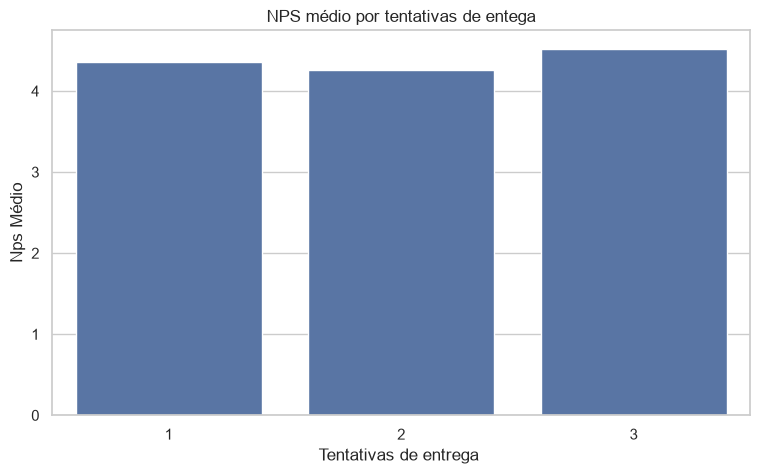

In [36]:
plt.figure (figsize=(9,5))

sns.barplot(
    data=media_nps_tentativas_entrega,
    x="tentativas_entrega",
    y="nps"
)

plt.title("NPS médio por tentativas de entega")
plt.xlabel("Tentativas de entrega ")
plt.ylabel("Nps Médio")


In [37]:
tabela = (
    pd.crosstab(
        df["tentativas_entrega"],
        df["categoria_nps"],
        normalize="index"
    ) * 100
).round(1)

tabela

categoria_nps,Detrator,Neutro,Promotor
tentativas_entrega,,,
1,74.4,17.2,8.4
2,76.1,17.2,6.7
3,71.6,19.3,9.1


### Análise

A análise das tentativas de entrega não evidenciou uma relação consistente entre essa variável e o NPS. As médias de satisfação permaneceram muito próximas entre clientes que receberam o pedido na primeira, segunda ou terceira tentativa de entrega.

O cruzamento entre as tentativas de entrega e as categorias do NPS também apresentou variações pouco expressivas na proporção de detratores, neutros e promotores, indicando que esse fator, isoladamente, não parece exercer influência significativa sobre a satisfação dos clientes.

Dessa forma, os resultados sugerem que fatores como atraso na entrega, quantidade de reclamações e contatos com o atendimento apresentam maior impacto na percepção dos clientes do que o número de tentativas necessárias para concluir a entrega.

## Tempo de relacionamento
O objetivo desta análise é verificar se o tempo de relacionamento dos clientes com a empresa influencia o NPS, avaliando se clientes mais antigos apresentam níveis de satisfação diferentes dos clientes mais recentes.

In [38]:
df["faixa_tempo_cliente"] = pd.cut(
    df["tempo_cliente_meses"],
    bins=[0, 6, 12, 24, 48, 120],
    labels=[
        "Até 6 meses",
        "6-12 meses",
        "13-24 meses",
        "25-48 meses",
        "Acima de 48 meses"
    ],
    include_lowest=True
)

In [39]:
media_nps_tempo_cliente = (
    df.groupby("faixa_tempo_cliente")["nps"]
      .mean()
      .reset_index()
)

media_nps_tempo_cliente

,faixa_tempo_cliente,nps
0,Até 6 meses,4.170492
1,6-12 meses,4.120000
2,13-24 meses,4.653036
3,25-48 meses,4.353066
4,Acima de 48 meses,4.379064


In [40]:
df["faixa_tempo_cliente"].value_counts().sort_index()

faixa_tempo_cliente
Até 6 meses           122
6-12 meses            120
13-24 meses           247
25-48 meses           473
Acima de 48 meses    1538
Name: count, dtype: int64

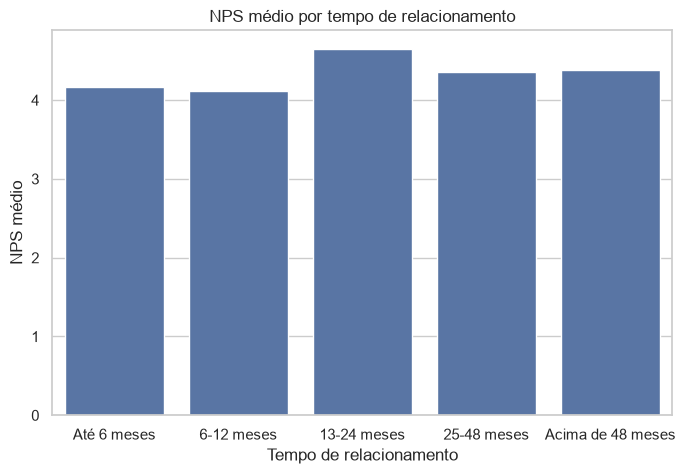

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=media_nps_tempo_cliente,
    x="faixa_tempo_cliente",
    y="nps"
)

plt.title("NPS médio por tempo de relacionamento")
plt.xlabel("Tempo de relacionamento")
plt.ylabel("NPS médio")

plt.show()

In [42]:
tabela = (
    pd.crosstab(
        df["faixa_tempo_cliente"],
        df["categoria_nps"],
        normalize="index"
    ) * 100
).round(1)

tabela

categoria_nps,Detrator,Neutro,Promotor
faixa_tempo_cliente,,,
Até 6 meses,77.0,17.2,5.7
6-12 meses,75.0,18.3,6.7
13-24 meses,71.7,19.0,9.3
25-48 meses,73.8,19.2,7.0
Acima de 48 meses,74.2,17.4,8.5


### Análise

Apesar de mais de 60% da base ser composta por clientes com mais de 48 meses de relacionamento, as médias de NPS permaneceram bastante semelhantes entre todas as faixas analisadas.

O cruzamento com as categorias de NPS também apresentou pequenas variações na proporção de detratores, neutros e promotores, sem indicar uma tendência consistente de melhora ou piora da satisfação conforme aumenta o tempo de relacionamento.

Esses resultados sugerem que o tempo de relacionamento, isoladamente, não exerce influência significativa sobre o NPS. Dessa forma, fatores operacionais, como quantidade de reclamações, contatos com o atendimento, atrasos na entrega e tempo de resolução, demonstraram maior impacto na percepção dos clientes.

##Recompra

O objetivo desta análise é verificar a relação entre a recompra e o NPS dos clientes, buscando identificar se clientes que voltam a comprar apresentam maiores níveis de satisfação.

In [43]:
media_nps_recompra_30_dias = (
    df.groupby("recompra_30_dias")["nps"]
     .mean()
     .reset_index()
)
media_nps_recompra_30_dias

,recompra_30_dias,nps
0,0,3.936196
1,1,9.009633


In [44]:
df["recompra_30_dias"].value_counts().sort_index()

recompra_30_dias
0    2282
1     218
Name: count, dtype: int64

In [45]:
tabela = (
    pd.crosstab(
        df["recompra_30_dias"],
        df["categoria_nps"],
        normalize="index"
    ) * 100
).round(1)

tabela

categoria_nps,Detrator,Neutro,Promotor
recompra_30_dias,,,
0,81.1,18.9,0.0
1,0.0,7.8,92.2


### Análise

Os clientes que realizaram recompra apresentaram NPS médio significativamente superior ao dos clientes que não voltaram a comprar. Entre os clientes que efetuaram uma nova compra, 92,2% foram classificados como promotores, enquanto entre aqueles que não recompuseram predominam os detratores (81,1%).

Esse resultado evidencia uma forte associação entre satisfação do cliente e recompra. Entretanto, a análise não permite afirmar que o NPS seja a causa direta desse comportamento, apenas que ambas as variáveis apresentam forte relação.

Além disso, apenas 218 clientes realizaram recompra, representando aproximadamente 8,7% da base analisada. Dessa forma, embora o resultado seja expressivo, ele deve ser interpretado considerando o reduzido número de clientes que efetuaram nova compra.

## Conclusão 


As análises realizadas permitiram identificar quais fatores exercem maior influência sobre o NPS e compreender quais aspectos da experiência do cliente devem receber maior atenção. Esse entendimento é fundamental para direcionar ações de melhoria com base em evidências, priorizando os fatores que mais impactam a satisfação dos clientes.

Os resultados demonstraram que o número de contatos com o atendimento, a quantidade de reclamações e os atrasos na entrega apresentam forte relação com a redução das notas de NPS, sendo os fatores de maior impacto identificados nesta etapa do estudo.

A partir desses resultados, as próximas análises serão direcionadas para um nível maior de detalhamento, investigando esses fatores por diferentes características dos clientes, como região e faixa etária, com o objetivo de identificar perfis mais afetados e apoiar a definição de estratégias de melhoria mais direcionadas.

# Análise por região

Nesta seção respondemos, para cada indicador, **qual região** apresenta os maiores valores médios/totais. Isso ajuda a identificar se algum grupo de clientes concentra mais reclamações, espera, atraso, contatos, compras ou desconto.

## Quem reclama mais?

In [46]:
reclamacoes_por_regiao = (
    df.groupby("regiao")["nps"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

reclamacoes_por_regiao

,regiao,nps
0,Sul,4.490979
1,Nordeste,4.421649
2,Norte,4.382609
3,Sudeste,4.373846
4,Centro-Oeste,4.209829


In [47]:
reclamacoes_por_regiao = (
    df.groupby("regiao")["reclamacoes"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

reclamacoes_por_regiao

,regiao,reclamacoes
0,Sudeste,4.242308
1,Centro-Oeste,4.177350
2,Nordeste,4.162887
3,Norte,4.110672
4,Sul,4.061420


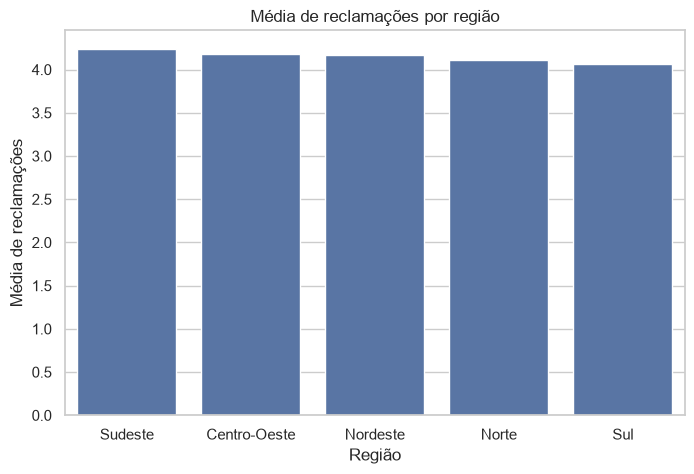

In [48]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=reclamacoes_por_regiao,
    x="regiao",
    y="reclamacoes",
    order=reclamacoes_por_regiao["regiao"]
)

plt.title("Média de reclamações por região")
plt.xlabel("Região")
plt.ylabel("Média de reclamações")
plt.show()

 A região Sudeste apresentou a maior média de reclamações por cliente (4,24). Esse resultado indica que os clientes dessa região enfrentam mais problemas ao longo da jornada de compra, tornando-a um ponto de atenção para a empresa. Esse resultado indica que a região merece atenção em análises futuras para identificar possíveis fatores que estejam contribuindo para o maior número de reclamações

In [49]:
## Quem espera mais tempo? (tempo de entrega)

In [50]:
tempo_entrega_por_regiao = (
    df.groupby("regiao")["tempo_entrega"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

tempo_entrega_por_regiao

,regiao,tempo_entrega
0,Sudeste,8.201923
1,Nordeste,8.160825
2,Sul,8.067179
3,Centro-Oeste,7.912393
4,Norte,7.758893


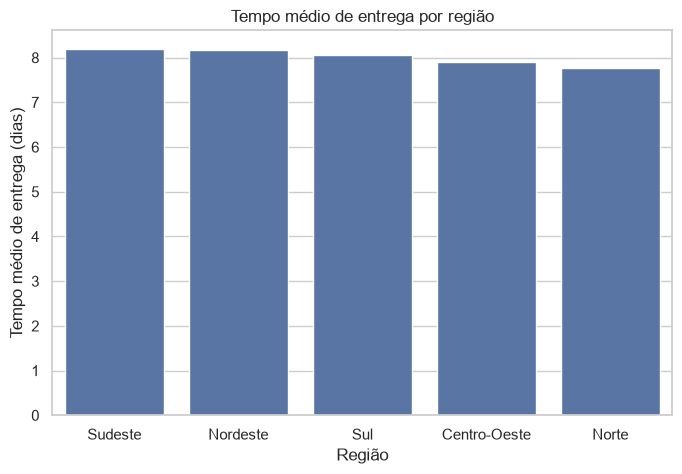

In [51]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=tempo_entrega_por_regiao,
    x="regiao",
    y="tempo_entrega",
    order=tempo_entrega_por_regiao["regiao"]
)

plt.title("Tempo médio de entrega por região")
plt.xlabel("Região")
plt.ylabel("Tempo médio de entrega (dias)")
plt.show()

Os clientes da região Sudeste apresentaram o maior tempo médio de resolução (8,2 dias). Como as análises anteriores demonstraram que maiores tempos de entrega estão associados à redução do NPS, esse resultado sugere que a demora logística pode estar impactando a satisfação dos clientes da região

In [52]:
## Quem recebe mais atraso?

In [53]:
atraso_por_regiao = (
    df.groupby("regiao")["atraso_entrega"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

atraso_por_regiao

,regiao,atraso_entrega
0,Centro-Oeste,2.222222
1,Sudeste,2.217308
2,Nordeste,2.185567
3,Sul,2.168906
4,Norte,2.144269


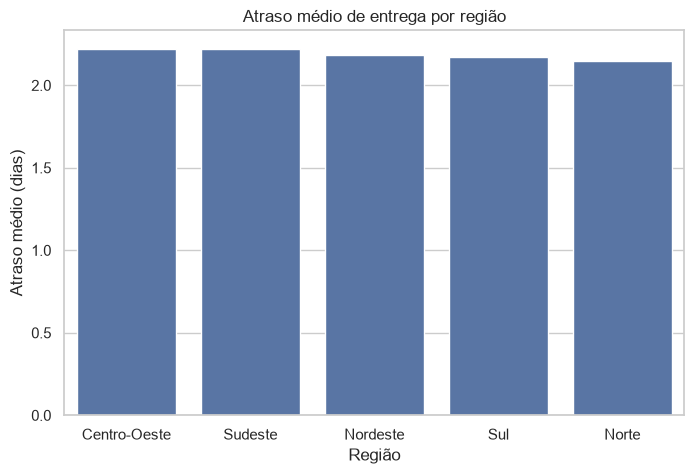

In [54]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=atraso_por_regiao,
    x="regiao",
    y="atraso_entrega",
    order=atraso_por_regiao["regiao"]
)

plt.title("Atraso médio de entrega por região")
plt.xlabel("Região")
plt.ylabel("Atraso médio (dias)")
plt.show()

A região Centro-Oeste apresentou o maior atraso médio nas entregas (2,2 dias). Considerando que atrasos na entrega representam um dos principais fatores de insatisfação do cliente, esse resultado sugere a necessidade de revisar os processos logísticos da região.

In [55]:
## Quem faz mais contatos? (atendimento)

In [56]:
contatos_por_regiao = (
    df.groupby("regiao")["contatos_atendimento"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

contatos_por_regiao

,regiao,contatos_atendimento
0,Centro-Oeste,1.591880
1,Sul,1.552783
2,Nordeste,1.507216
3,Sudeste,1.494231
4,Norte,1.456522


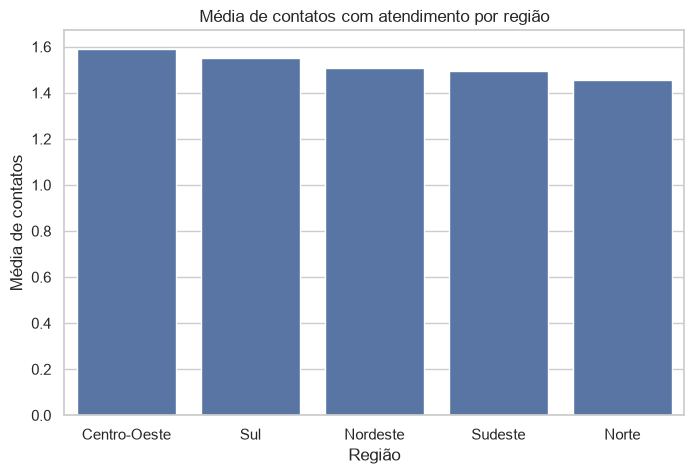

In [57]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=contatos_por_regiao,
    x="regiao",
    y="contatos_atendimento",
    order=contatos_por_regiao["regiao"]
)

plt.title("Média de contatos com atendimento por região")
plt.xlabel("Região")
plt.ylabel("Média de contatos")
plt.show()

Os clientes do Centro-Oeste realizaram, em média, mais contatos com o atendimento (1,6 por cliente). Como análises anteriores mostraram que o aumento da quantidade de contatos está associado à redução do NPS, esse comportamento pode indicar dificuldades na resolução dos problemas já no primeiro atendimento.

In [58]:
## Quem compra mais? (valor de pedido)

In [59]:
# Valor médio por pedido e valor total comprado por região
compras_por_regiao = (
    df.groupby("regiao")
      .agg(
          valor_medio_pedido=("valor_pedido", "mean"),
          valor_total_comprado=("valor_pedido", "sum"),
          qtd_pedidos=("id_pedido", "count")
      )
      .sort_values("valor_total_comprado", ascending=False)
      .reset_index()
)

compras_por_regiao

,regiao,valor_medio_pedido,valor_total_comprado,qtd_pedidos
0,Sul,436.583570,227460.04,521
1,Norte,434.571047,219892.95,506
2,Nordeste,443.623320,215157.31,485
3,Sudeste,413.531000,215036.12,520
4,Centro-Oeste,444.664380,208102.93,468


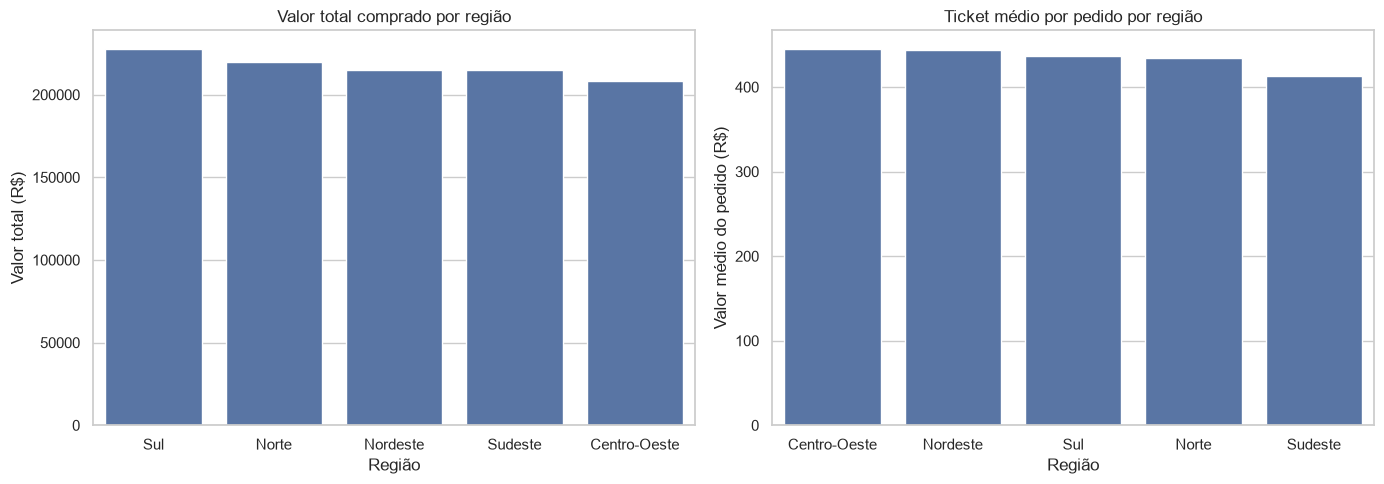

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=compras_por_regiao,
    x="regiao", y="valor_total_comprado",
    order=compras_por_regiao["regiao"],
    ax=axes[0]
)
axes[0].set_title("Valor total comprado por região")
axes[0].set_xlabel("Região")
axes[0].set_ylabel("Valor total (R$)")

sns.barplot(
    data=compras_por_regiao,
    x="regiao", y="valor_medio_pedido",
    order=compras_por_regiao.sort_values("valor_medio_pedido", ascending=False)["regiao"],
    ax=axes[1]
)
axes[1].set_title("Ticket médio por pedido por região")
axes[1].set_xlabel("Região")
axes[1].set_ylabel("Valor médio do pedido (R$)")

plt.tight_layout()
plt.show()

A região Sul concentrou o maior volume financeiro em vendas, indicando maior participação no faturamento da empresa. Já o Centro-Oeste apresentou o maior valor médio por pedido, sugerindo que seus clientes realizam compras de maior valor individual.

In [61]:
## Quem recebe mais desconto?

In [62]:
desconto_por_regiao = (
    df.groupby("regiao")
      .agg(
          desconto_medio=("valor_desconto", "mean"),
          desconto_total=("valor_desconto", "sum")
      )
      .sort_values("desconto_medio", ascending=False)
      .reset_index()
)

desconto_por_regiao

,regiao,desconto_medio,desconto_total
0,Sudeste,30.666538,15946.60
1,Nordeste,30.248948,14670.74
2,Centro-Oeste,29.921795,14003.40
3,Sul,29.104491,15163.44
4,Norte,28.813972,14579.87


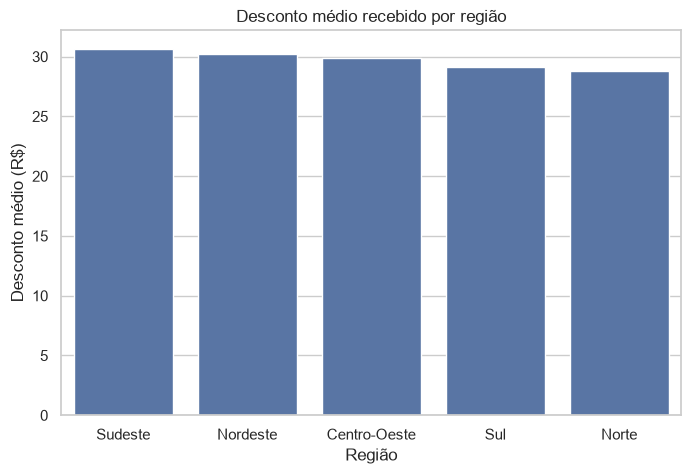

In [63]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=desconto_por_regiao,
    x="regiao",
    y="desconto_medio",
    order=desconto_por_regiao["regiao"]
)

plt.title("Desconto médio recebido por região")
plt.xlabel("Região")
plt.ylabel("Desconto médio (R$)")
plt.show()

A região Sudeste apresentou o maior desconto médio concedido aos clientes (R$ 30,67). Esse resultado pode indicar uma estratégia comercial mais agressiva ou a necessidade de compensar problemas operacionais percebidos pelos consumidores.

## Resumo

A célula abaixo consolida, em uma única tabela, qual região lidera em cada indicador (reclamações, tempo de entrega, atraso, contatos, compras e desconto), facilitando a leitura conjunta dos resultados.

In [64]:
resumo = pd.DataFrame({
    "indicador": [
        "Mais reclamações",
        "Maior tempo de entrega",
        "Maior atraso",
        "Mais contatos de atendimento",
        "Maior valor total comprado",
        "Maior desconto médio",
    ],
    "regiao_lider": [
        reclamacoes_por_regiao.iloc[0]["regiao"],
        tempo_entrega_por_regiao.iloc[0]["regiao"],
        atraso_por_regiao.iloc[0]["regiao"],
        contatos_por_regiao.iloc[0]["regiao"],
        compras_por_regiao.iloc[0]["regiao"],
        desconto_por_regiao.iloc[0]["regiao"],
    ],
    "valor": [
        round(reclamacoes_por_regiao.iloc[0]["reclamacoes"], 2),
        round(tempo_entrega_por_regiao.iloc[0]["tempo_entrega"], 2),
        round(atraso_por_regiao.iloc[0]["atraso_entrega"], 2),
        round(contatos_por_regiao.iloc[0]["contatos_atendimento"], 2),
        round(compras_por_regiao.iloc[0]["valor_total_comprado"], 2),
        round(desconto_por_regiao.iloc[0]["desconto_medio"], 2),
    ]
})

resumo

,indicador,regiao_lider,valor
0,Mais reclamações,Sudeste,4.24
1,Maior tempo de entrega,Sudeste,8.20
2,Maior atraso,Centro-Oeste,2.22
3,Mais contatos de atendimento,Centro-Oeste,1.59
4,Maior valor total comprado,Sul,227460.04
5,Maior desconto médio,Sudeste,30.67


A análise regional evidenciou diferenças importantes entre as regiões avaliadas. O Sudeste apresentou os maiores índices de reclamações, maior tempo médio de entrega e maior desconto médio concedido aos clientes, indicando oportunidades de melhoria nos processos e na experiência do consumidor. O Centro-Oeste destacou-se pelos maiores atrasos nas entregas, maior quantidade de contatos com o atendimento e maior ticket médio por pedido, sugerindo um perfil de compras de maior valor, porém acompanhado de maiores demandas operacionais. Já a região Sul concentrou o maior volume financeiro em vendas, demonstrando elevada participação no faturamento da empresa. Esses resultados reforçam que o comportamento dos clientes varia entre as regiões, tornando relevante a adoção de estratégias específicas para cada contexto.

Além de contribuir para a melhoria da satisfação dos clientes, o aperfeiçoamento dos processos operacionais pode reduzir a necessidade de concessão de descontos relacionados à recuperação da experiência do cliente, gerando também ganhos financeiros para a empresa.

Esses resultados reforçam a importância de priorizar ações nas regiões que concentram os maiores indicadores de problemas operacionais, permitindo direcionar investimentos de forma mais eficiente e maximizar tanto a satisfação dos clientes quanto os resultados financeiros da empresa.

# Análise por idade

Com base nas diferenças observadas entre as regiões, a próxima etapa consiste em verificar se esse comportamento também varia conforme a idade dos clientes, buscando identificar perfis específicos que concentram maiores índices de satisfação ou insatisfação.

In [65]:
df["faixa_idade"] = pd.cut(
    df["idade"],
    bins=[18, 25, 35, 45, 55, 70],
    labels=[
        "18-25 anos",
        "26-35 anos",
        "36-45 anos",
        "46-55 anos",
        "56-70 anos"
    ],
    include_lowest=True
)

In [66]:
media_nps_idade = (
    df.groupby("faixa_idade")["nps"]
      .mean()
      .reset_index()
)

media_nps_idade

,faixa_idade,nps
0,18-25 anos,4.476607
1,26-35 anos,4.562151
2,36-45 anos,4.120116
3,46-55 anos,4.413675
4,56-70 anos,4.369138


In [67]:
reclamacoes_por_idade = (
    df.groupby("faixa_idade")["reclamacoes"]
      .mean()
      .reset_index()
)

reclamacoes_por_idade 

,faixa_idade,reclamacoes
0,18-25 anos,4.115681
1,26-35 anos,4.045161
2,36-45 anos,4.239845
3,46-55 anos,4.188034
4,56-70 anos,4.148260


In [68]:
tempo_entrega_por_idade = (
    df.groupby("faixa_idade")["tempo_entrega"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

tempo_entrega_por_idade

,faixa_idade,tempo_entrega
0,46-55 anos,8.243590
1,56-70 anos,8.102874
2,18-25 anos,8.035990
3,36-45 anos,7.943907
4,26-35 anos,7.759140


In [69]:
tempo_contato_por_idade = (
    df.groupby("faixa_idade")["contatos_atendimento"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

tempo_contato_por_idade

,faixa_idade,contatos_atendimento
0,36-45 anos,1.584139
1,56-70 anos,1.568835
2,46-55 anos,1.512821
3,18-25 anos,1.462725
4,26-35 anos,1.432258


In [70]:
#Nota: A métrica de recompra corresponde à proporção de clientes que  realizaram uma nova compra em até 30 dias, apresentada em percentual (%).

recompra_idade = (
    df.groupby("faixa_idade")["recompra_30_dias"]
      .mean()
      .mul(100)
      .round(1)
      .reset_index()
)
recompra_idade

,faixa_idade,recompra_30_dias
0,18-25 anos,9.0
1,26-35 anos,9.9
2,36-45 anos,6.6
3,46-55 anos,9.4
4,56-70 anos,8.9


In [71]:
ticket_medio_idade = (
    df.groupby("faixa_idade")["valor_pedido"]
      .mean()
      .round(2)
      .reset_index()
)

ticket_medio_idade

,faixa_idade,valor_pedido
0,18-25 anos,429.56
1,26-35 anos,436.59
2,36-45 anos,425.63
3,46-55 anos,442.93
4,56-70 anos,436.00


In [72]:
resumo_idade = pd.DataFrame({

    "Indicador":[
        "NPS",
        "Reclamações",
        "Tempo entrega",
        "Contatos",
        "Recompra (%)",
        "Ticket médio"
    ],

    "Maior faixa":[
        media_nps_idade.loc[media_nps_idade["nps"].idxmax(),"faixa_idade"],
        reclamacoes_por_idade.loc[reclamacoes_por_idade["reclamacoes"].idxmax(),"faixa_idade"],
        tempo_entrega_por_idade.loc[tempo_entrega_por_idade["tempo_entrega"].idxmax(),"faixa_idade"],
        tempo_contato_por_idade.loc[tempo_contato_por_idade["contatos_atendimento"].idxmax(),"faixa_idade"],
        recompra_idade.loc[recompra_idade["recompra_30_dias"].idxmax(),"faixa_idade"],
        ticket_medio_idade.loc[ticket_medio_idade["valor_pedido"].idxmax(),"faixa_idade"]
    ],

    "Maior valor":[
        round(media_nps_idade["nps"].max(),2),
        round(reclamacoes_por_idade["reclamacoes"].max(),2),
        round(tempo_entrega_por_idade["tempo_entrega"].max(),2),
        round(tempo_contato_por_idade["contatos_atendimento"].max(),2),
        round(recompra_idade["recompra_30_dias"].max(),2),
        round(ticket_medio_idade["valor_pedido"].max(),3)
    ],

    "Menor faixa":[
        media_nps_idade.loc[media_nps_idade["nps"].idxmin(),"faixa_idade"],
        reclamacoes_por_idade.loc[reclamacoes_por_idade["reclamacoes"].idxmin(),"faixa_idade"],
        tempo_entrega_por_idade.loc[tempo_entrega_por_idade["tempo_entrega"].idxmin(),"faixa_idade"],
        tempo_contato_por_idade.loc[tempo_contato_por_idade["contatos_atendimento"].idxmin(),"faixa_idade"],
        recompra_idade.loc[recompra_idade["recompra_30_dias"].idxmin(),"faixa_idade"],
        ticket_medio_idade.loc[ticket_medio_idade["valor_pedido"].idxmin(),"faixa_idade"]
    ],

    "Menor valor":[
        round(media_nps_idade["nps"].min(),2),
        round(reclamacoes_por_idade["reclamacoes"].min(),2),
        round(tempo_entrega_por_idade["tempo_entrega"].min(),2),
        round(tempo_contato_por_idade["contatos_atendimento"].min(),2),
        round(recompra_idade["recompra_30_dias"].min(),2),
        round(ticket_medio_idade["valor_pedido"].min(),3)
    ]
})
resumo_idade

,Indicador,Maior faixa,Maior valor,Menor faixa,Menor valor
0,NPS,26-35 anos,4.56,36-45 anos,4.12
1,Reclamações,36-45 anos,4.24,26-35 anos,4.05
2,Tempo entrega,46-55 anos,8.24,26-35 anos,7.76
3,Contatos,36-45 anos,1.58,26-35 anos,1.43
4,Recompra (%),26-35 anos,9.90,36-45 anos,6.60
5,Ticket médio,46-55 anos,442.93,36-45 anos,425.63


##Conclusão 

Os indicadores analisados apresentaram baixa variação entre as faixas etárias. O NPS variou apenas 0,44 ponto, as reclamações oscilaram cerca de 0,19 ocorrência por cliente, os contatos com o atendimento variaram aproximadamente 0,15 contato por cliente e o tempo médio de entrega apresentou diferença inferior a 0,5 dia entre as faixas. A taxa de recompra também apresentou pequena variação, de aproximadamente 3,3 pontos percentuais, enquanto o ticket médio permaneceu em patamares semelhantes. Esses resultados indicam que a faixa etária, isoladamente, não é um fator determinante para explicar a satisfação dos clientes ou o desempenho operacional, sugerindo que variáveis como região e processos operacionais exercem maior influência sobre os indicadores analisados.

#  Análise de Correlação entre as Variáveis

Validação dos resultados por meio da matriz de correlação

Após a análise individual dos principais indicadores, foi construída uma matriz de correlação para verificar se os relacionamentos observados também se confirmavam de forma conjunta entre as variáveis. Essa etapa permite identificar a intensidade e a direção das relações lineares, servindo como uma validação estatística dos padrões encontrados ao longo da análise exploratória.

In [73]:
colunas_numericas = df.select_dtypes(include='number')

In [74]:
correlacao = colunas_numericas.corr()

correlacao

,id_cliente,idade,tempo_cliente_meses,id_pedido,valor_pedido,quantidade_itens,valor_desconto,parcelas,tempo_entrega,atraso_entrega,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao,nps,recompra_30_dias,reclamacoes,csat,nps_arredondado
id_cliente,1.000000,-0.025013,0.024351,1.000000,0.011571,-0.007856,-0.007944,0.011637,0.013572,-0.018096,-0.003484,0.008900,0.011174,-0.000063,0.015162,0.002462,-0.011988,0.007807,0.012457
idade,-0.025013,1.000000,0.029889,-0.025013,0.011991,-0.004716,0.007017,-0.050824,0.022542,-0.002094,-0.015174,-0.026088,0.032706,0.005458,-0.009936,0.009017,0.008211,-0.015125,-0.008848
tempo_cliente_meses,0.024351,0.029889,1.000000,0.024351,0.011507,-0.003566,0.015332,0.000205,-0.017653,0.001198,-0.017503,-0.026009,-0.008960,-0.005167,-0.009711,0.024008,-0.009167,-0.000267,-0.013194
id_pedido,1.000000,-0.025013,0.024351,1.000000,0.011571,-0.007856,-0.007944,0.011637,0.013572,-0.018096,-0.003484,0.008900,0.011174,-0.000063,0.015162,0.002462,-0.011988,0.007807,0.012457
valor_pedido,0.011571,0.011991,0.011507,0.011571,1.000000,0.003973,0.011670,0.042265,-0.021890,0.005971,-0.019107,-0.005792,0.032823,-0.014299,0.036990,0.023443,0.001893,0.000807,0.035779
quantidade_itens,-0.007856,-0.004716,-0.003566,-0.007856,0.003973,1.000000,0.023730,-0.002980,0.020323,-0.014567,-0.011353,-0.020238,-0.014553,0.017519,0.011468,0.012073,0.024986,-0.005639,0.014429
valor_desconto,-0.007944,0.007017,0.015332,-0.007944,0.011670,0.023730,1.000000,0.005823,-0.012101,-0.049742,0.020587,0.026542,0.016097,-0.017247,0.025104,0.014534,0.000792,0.040063,0.029046
parcelas,0.011637,-0.050824,0.000205,0.011637,0.042265,-0.002980,0.005823,1.000000,-0.007901,-0.026633,-0.000634,0.023752,0.025483,0.015277,0.023718,-0.010714,-0.001881,0.001777,0.028124
tempo_entrega,0.013572,0.022542,-0.017653,0.013572,-0.021890,0.020323,-0.012101,-0.007901,1.000000,-0.006589,-0.017541,-0.019562,0.007706,0.021217,0.000925,0.006094,-0.008998,-0.024835,0.002107
atraso_entrega,-0.018096,-0.002094,0.001198,-0.018096,0.005971,-0.014567,-0.049742,-0.026633,-0.006589,1.000000,0.003779,0.005189,-0.024167,-0.015297,-0.597260,-0.304014,0.190225,-0.459051,-0.595482


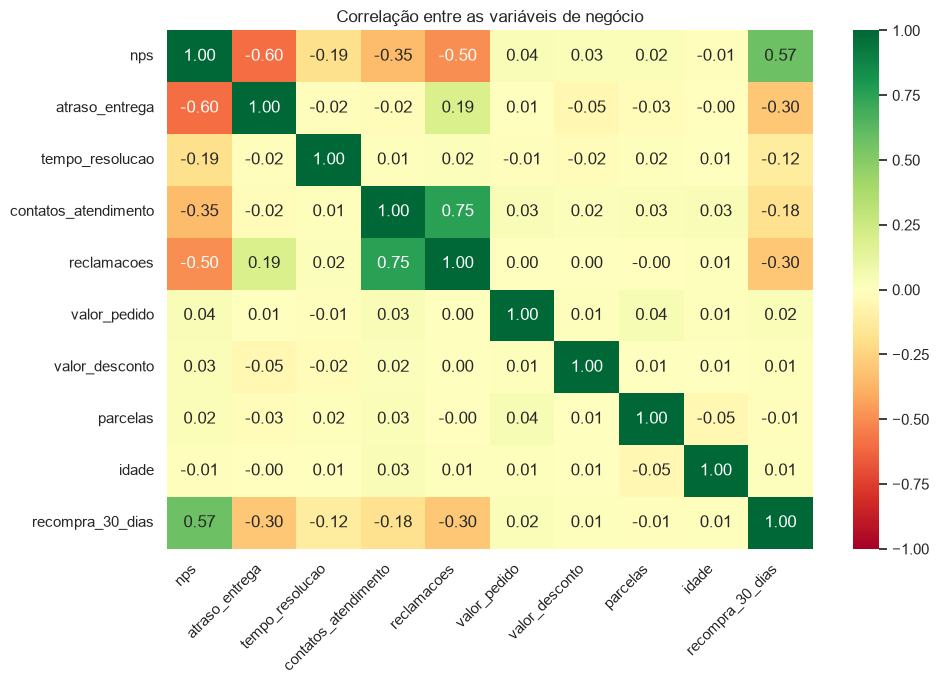

In [76]:
variaveis = df[
    [
        'nps',
        'atraso_entrega',
        'tempo_resolucao',
        'contatos_atendimento',
        'reclamacoes',
        'valor_pedido',
        'valor_desconto',
        'parcelas',
        'idade',
        'recompra_30_dias'
    ]
]

corr = variaveis.corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    fmt='.2f'
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title('Correlação entre as variáveis de negócio')

plt.tight_layout()
plt.show()

A matriz confirma que atraso na entrega, reclamações e contatos com o atendimento apresentam correlação negativa com o NPS, enquanto a recompra apresenta correlação positiva. Em contrapartida, variáveis como idade, valor do pedido, descontos e número de parcelas apresentaram correlações próximas de zero, indicando baixa influência direta sobre a satisfação do cliente.

#Recomendações estratégicas

Com base nas análises realizadas, recomenda-se que a empresa priorize ações voltadas às regiões e processos que apresentaram maior impacto sobre o NPS.

As principais recomendações são:

Revisar os processos logísticos nas regiões com maior tempo de entrega e atraso, buscando reduzir o tempo de espera dos clientes.

Investigar as causas do elevado número de reclamações e contatos com o atendimento, principalmente na região Sudeste e Centro-Oeste.

Atuar na resolução definitiva dos problemas já no primeiro contato, reduzindo a necessidade de múltiplos atendimentos.

Avaliar os descontos concedidos aos clientes, identificando se estão sendo utilizados como compensação por falhas operacionais e reduzindo esse custo por meio da melhoria dos processos.

Priorizar melhorias operacionais em vez de ações direcionadas à idade dos clientes, uma vez que a análise demonstrou que a faixa etária apresentou pouca influência sobre os indicadores avaliados.

#Conclusão Geral

O presente estudo permitiu identificar os principais fatores associados à satisfação dos clientes. As análises demonstraram que reclamações, contatos com o atendimento, atrasos nas entregas e recompra apresentam relação mais significativa com o NPS do que características demográficas, como a faixa etária.

A análise regional evidenciou diferenças importantes entre as regiões, indicando oportunidades de melhoria operacional específicas para cada contexto. Em especial, a região Sudeste concentrou maiores índices de reclamações, maior tempo médio de entrega e maior desconto concedido aos clientes, sugerindo que melhorias operacionais podem gerar benefícios tanto para a experiência do consumidor quanto para a redução de custos.

Dessa forma, conclui-se que a utilização de análise de dados permite identificar oportunidades de otimização dos processos, apoiar a tomada de decisão e direcionar investimentos para ações com maior potencial de impacto sobre a satisfação e os resultados do negócio.